# [실습] 이변량분석(y-숫자)

* 카시트에 대해서 지역 매장 별 매출액을 예측하고자 한다.

# 1.환경준비

## 1.1. 라이브러리 불러오기

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst

## 1.2. 데이터 로딩

|	변수명	|	설명	|	구분	|
|	----	|	----	|	----	|
|	Sales 	|	 각 지역 판매량(단위 : 1000개)	|	Target	|
|	CompPrice 	|	지역별 경쟁사 판매가격(달러)	|	feature	|
|	Advertising 	|	 각 지역, 회사의 광고 예산(단위 : 1000달러)	|	feature	|
|	Population 	|	 지역 인구수(단위 : 1000명)	|	feature	|
|	Price 	|	 자사 지역별 판매가격(달러)	|	feature	|
|	ShelveLoc 	|	 진열상태	|	feature	|
|	Age 	|	 지역 인구의 평균 연령	|	feature	|
|	US 	|	 매장이 미국에 있는지 여부	|	feature	|
|	Income 	|	 지역 주민 평균 소득	|	feature	|
|	Urban 	|	 매장이 도시에 있는지 여부	|	feature	|



In [63]:
df = pd.read_csv('./../51_실습1/data/Carseats.csv')
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,Yes,No


In [64]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    str    
 7   Age          400 non-null    int64  
 8   Urban        400 non-null    str    
 9   US           400 non-null    str    
dtypes: float64(1), int64(6), str(3)
memory usage: 31.4 KB




---



# 2.숫자형 X --> Y

* 모든 숫자형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.

① 시각화 : scatter, jointplot  
② 수치화 : 상관분석

In [66]:
def getGraph(df, x, y):
  plt.figure(figsize=(16,4))
  plt.subplot(1,2,1)
  plt.scatter(df[x], df[y])

  plt.subplot(1,2,2)
  sns.regplot(x=x, y=y, data=df, color='blue', line_kws={'linestyle':'--'}, scatter_kws={'s':10, 'alpha':0.5})
  plt.show()

  sns.jointplot(x=x, y=y, data=df)
  plt.show()


In [67]:
def getStatics(df, x, y):
    print(spst.pearsonr(df[x], df[y]))

### 2.1. Advertising -> Sales

1) 시각화 : scatter(regplot), jointplot

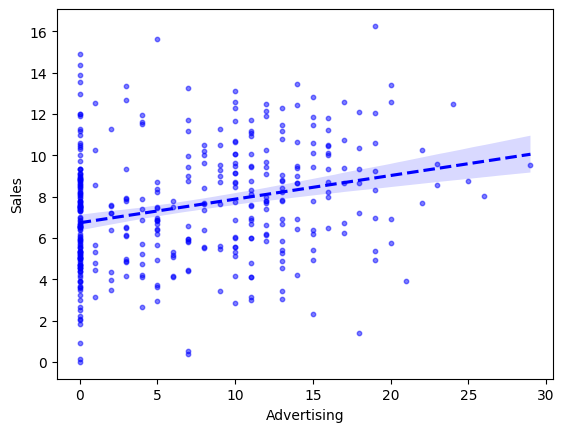

In [68]:
sns.regplot(x='Advertising', y='Sales', data=df, color='blue', line_kws={'linestyle':'--'}, scatter_kws={'s':10, 'alpha':0.5})
plt.show()

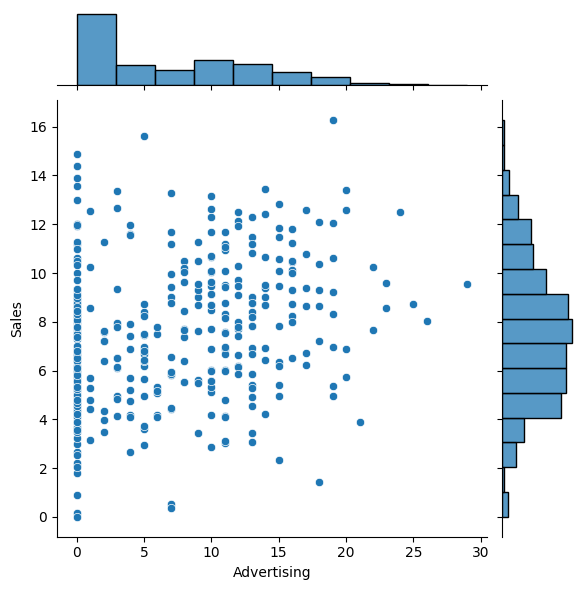

In [69]:
sns.jointplot(x='Advertising', y='Sales', data=df)
plt.show()

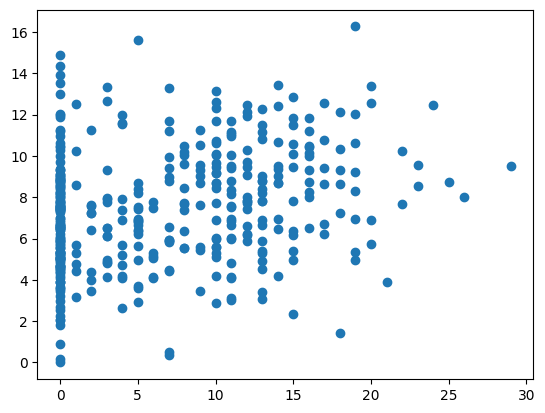

In [70]:
plt.scatter(df['Advertising'], df['Sales'])
plt.show()

2) 수치화 : 상관분석

In [71]:
getStatics(df,'Advertising','Sales')

PearsonRResult(statistic=np.float64(0.269506781376902), pvalue=np.float64(4.37767711030261e-08))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 0.26의 상관관계를 보아 약한 양의 상관관계를 가지고있고
- p_value는 0.05보다 작으므로, 통계적으로 유의미한 관계를 가지고있다고 볼 수 있다.

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    str    
 7   Age          400 non-null    int64  
 8   Urban        400 non-null    str    
 9   US           400 non-null    str    
dtypes: float64(1), int64(6), str(3)
memory usage: 31.4 KB


[추가] 광고비 0 빼고 분석해보기

In [73]:
df_zero = df[df['Advertising']!=0]

# df_zero = df.loc[df['Advertising']!=0]

df_zero.head()
df_zero.info()

<class 'pandas.DataFrame'>
Index: 256 entries, 0 to 398
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        256 non-null    float64
 1   CompPrice    256 non-null    int64  
 2   Income       256 non-null    int64  
 3   Advertising  256 non-null    int64  
 4   Population   256 non-null    int64  
 5   Price        256 non-null    int64  
 6   ShelveLoc    256 non-null    str    
 7   Age          256 non-null    int64  
 8   Urban        256 non-null    str    
 9   US           256 non-null    str    
dtypes: float64(1), int64(6), str(3)
memory usage: 22.0 KB


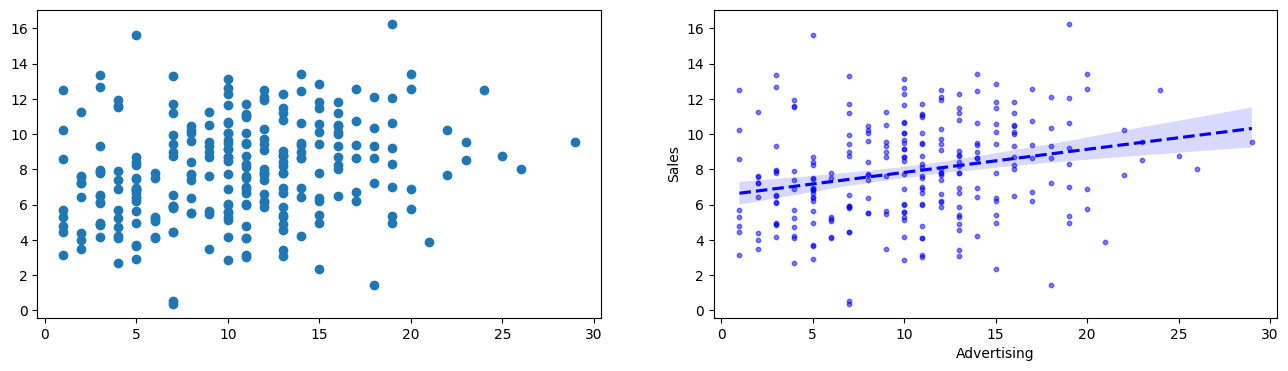

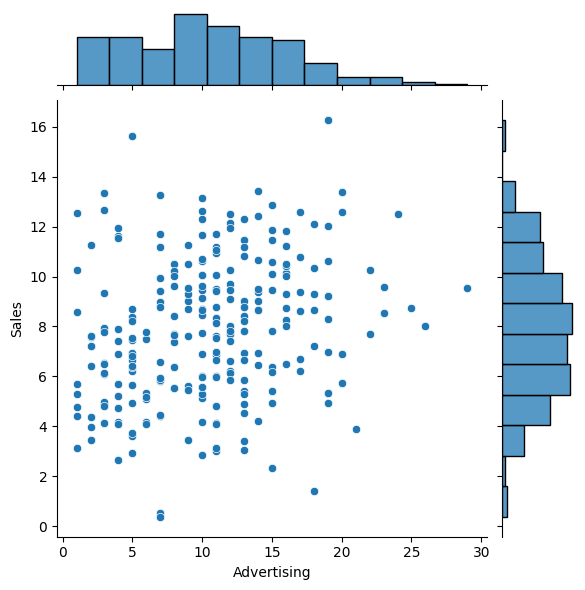

PearsonRResult(statistic=np.float64(0.2571829256169392), pvalue=np.float64(3.112672883086105e-05))


In [74]:
getGraph(df_zero, 'Advertising', 'Sales')
getStatics(df_zero, 'Advertising', 'Sales')

- 기존의 0.26에서 0.25로 상관관계계수가 줄었지만 여전히 약한 양의 상관관계를 보이고있고.
- 기존의 0.00000004에서 0.00003으로 p_value가 늘어나긴했지만 여전히 통계적으로 유의미하다고 볼 수 있다.

### 2.2. Population -> Sales

1) 시각화 : scatter(regplot), jointplot

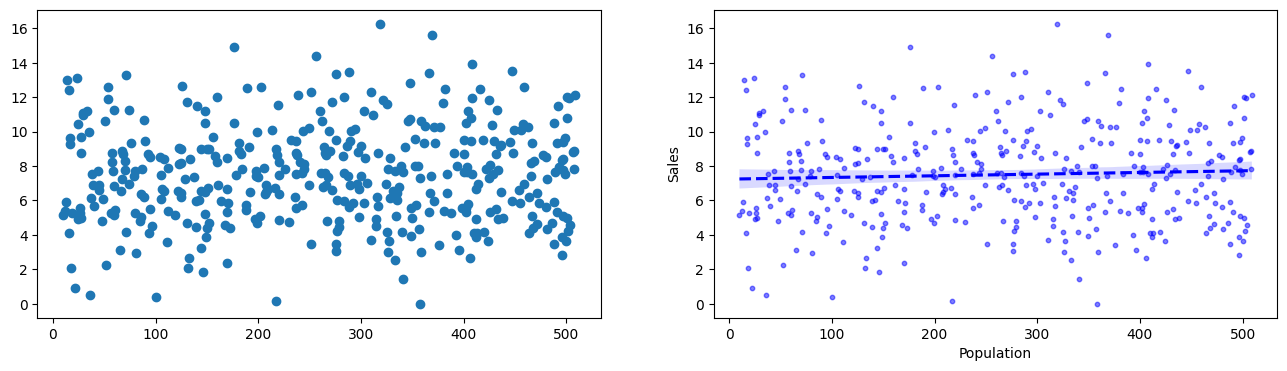

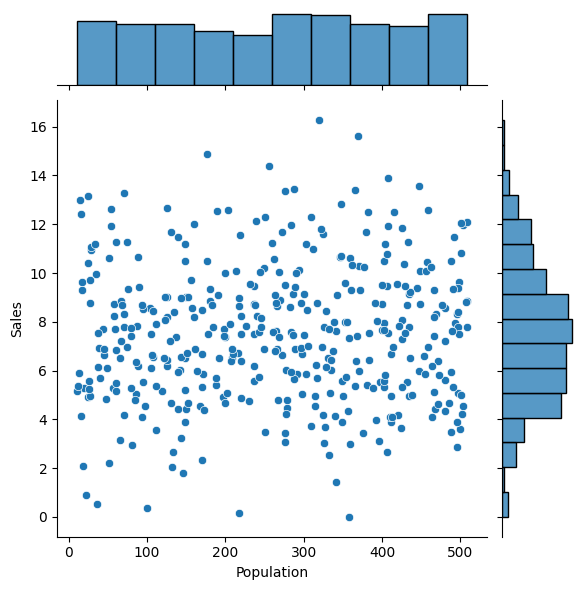

In [75]:

getGraph(df, 'Population','Sales')

2) 수치화 : 상관분석

In [76]:
getStatics(df, 'Population','Sales')

PearsonRResult(statistic=np.float64(0.05047098447203921), pvalue=np.float64(0.3139816093190477))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 0.05의 상관관계를 보아 거의 상관관계가 없다고 볼 수 있다.
- p_value는 0.3로 통계적 유의미한 관계가 없다. 해당변수는 Sales에 영향읆 미치지않는다.

### 2.3. Price -> Sales

1) 시각화 : scatter(regplot), jointplot

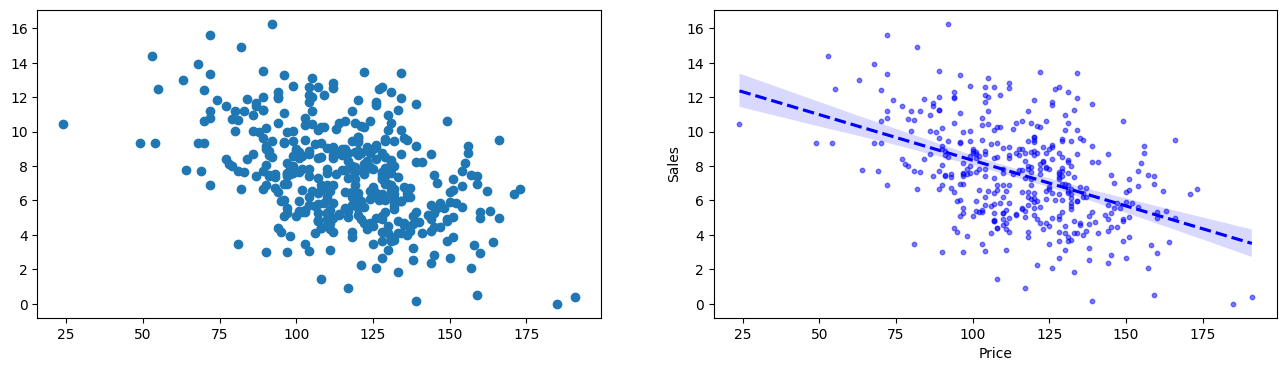

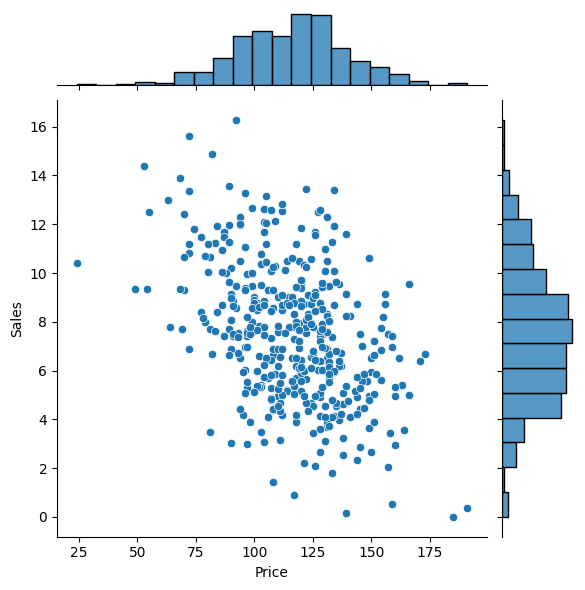

In [77]:

getGraph(df, 'Price','Sales')

2) 수치화 : 상관분석

In [78]:

getStatics(df, 'Price','Sales')

PearsonRResult(statistic=np.float64(-0.44495072784657275), pvalue=np.float64(7.618187011912755e-21))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 상관관계 계수가 -0.44로 강한 음의 상관관계를 가지고있다.
- pvalue가 거의 0에 가까운 것으로 보아 Price와 Sales는 통계적으로 유의미한 관계가있다.
- 가격이 낮아질수록 판매량이 유의미하게 증가한다.

### 2.4. Age -> Sales

1) 시각화 : scatter(regplot), jointplot

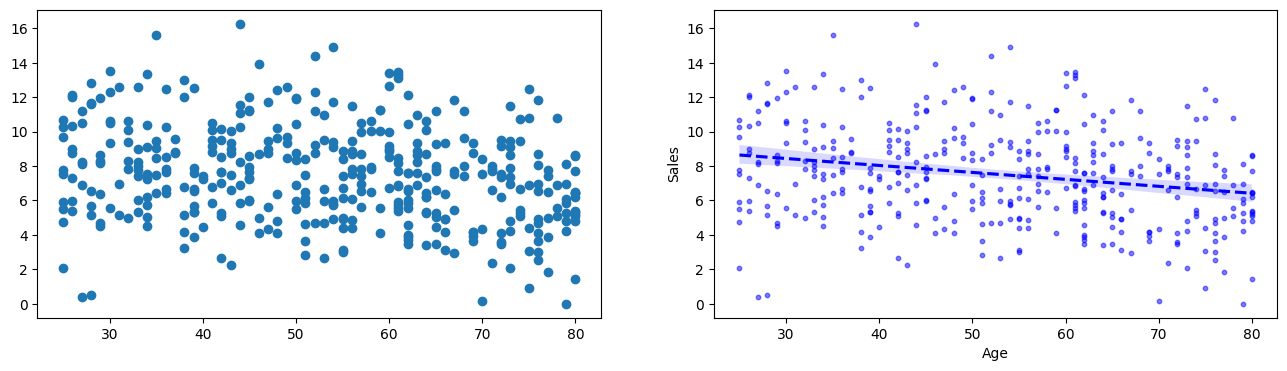

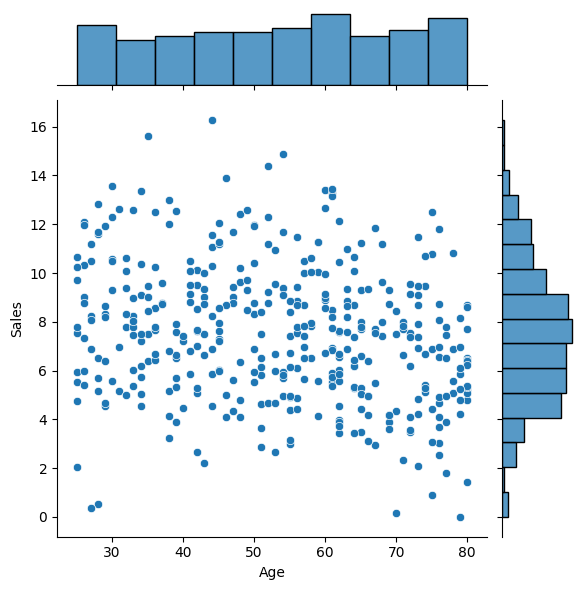

In [79]:

getGraph(df, 'Age','Sales')

2) 수치화 : 상관분석

In [80]:
getStatics(df, 'Age','Sales')

PearsonRResult(statistic=np.float64(-0.23181543960457648), pvalue=np.float64(2.7889498393714207e-06))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 상관계수가 -0.23으로 중간정도의 음의 상관관계를 가진다.
- pvalue가 0.000002로 통계적으로 유의미한 관계가 있다.
- Age가 낮을수록 sale가 증가한다.

### 2.5. CompPrice -> Sales

1) 시각화 : scatter(regplot), jointplot

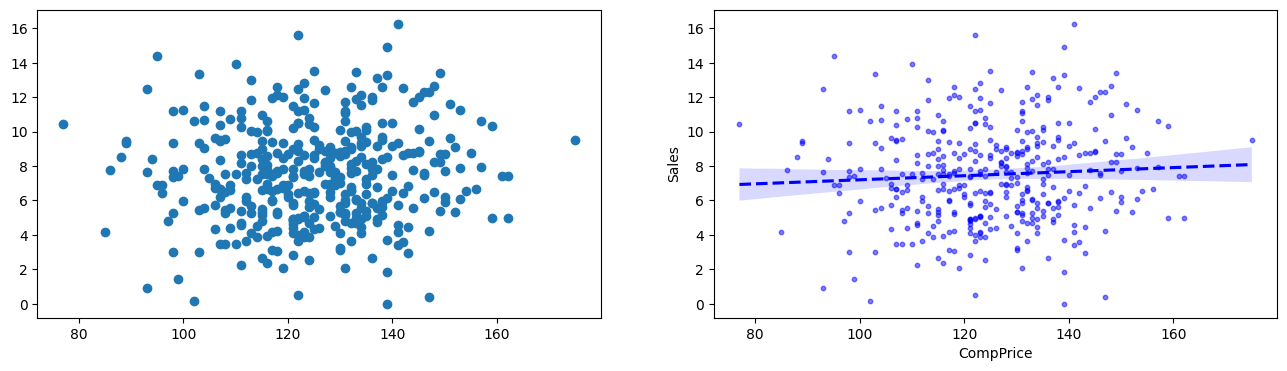

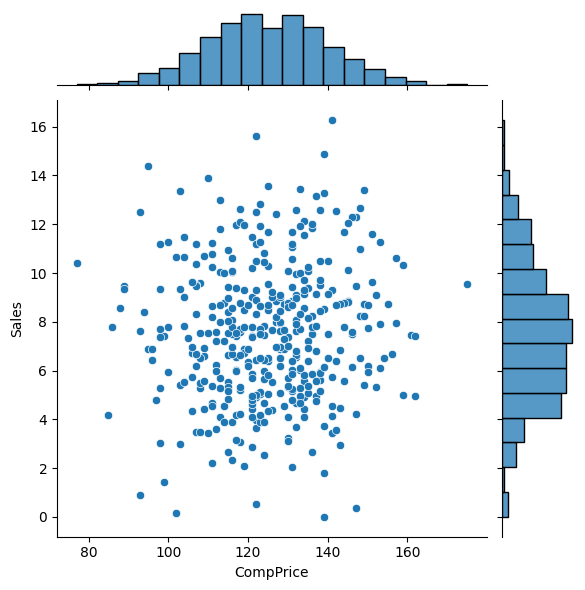

In [81]:

getGraph(df,'CompPrice','Sales')

2) 수치화 : 상관분석

In [82]:
getStatics(df,'CompPrice','Sales')

PearsonRResult(statistic=np.float64(0.06407872955062154), pvalue=np.float64(0.20093982894184056))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.


- 상관관계 계수가 0.06으로 선형성이 거의 없다.
- pvalue가 0.2로 통계적으로 유의미하지않다.
- 경쟁사의 가격은 우리의 판매량에 영향을 미치지 않는다.

- 가격 경쟁력 이라는 변수를 새로 만들어 봅시다.

In [87]:
df['df_comp'] = df['CompPrice'] - df['Price']

df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US,df_comp
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes,18
1,11.22,111,48,16,260,83,Good,65,Yes,Yes,28
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes,33
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes,20
4,4.15,141,64,3,340,128,Bad,38,Yes,No,13


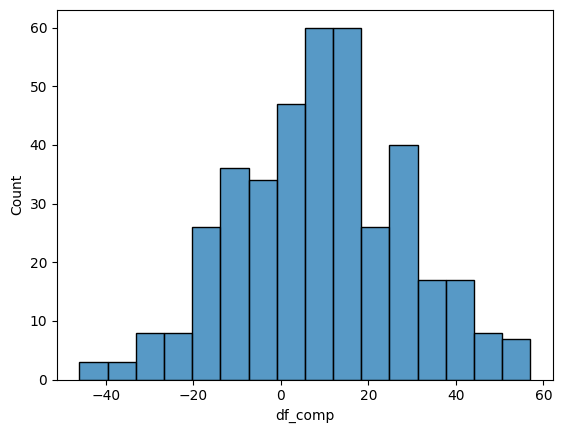

In [90]:
sns.histplot(x='df_comp', data=df)
plt.show()

- PriceDiff = CompPrice - Price
- 자사가격이 타사가격보다 낮을 경우 0.59의 강한 양의상관관계가 나타난다.
- p_vlaue또한 0에 수렴하는 값으로 통계적 유의미성이 상당히 크다.
- 단순 자사가격과 타사가격만 비교했을 때는 연관성이 없어보였지만, 가격경쟁력으로 비교를 하자 유의미한 차이를 볼 수 있다.
- 이는 단순히 가격이 싸고, 비싸고보다 경쟁사와의 가격차이가 판매량에 영향을 끼친다는 것을 보여준다

### 2.6. Income -> Sales

1) 시각화 : scatter(regplot), jointplot

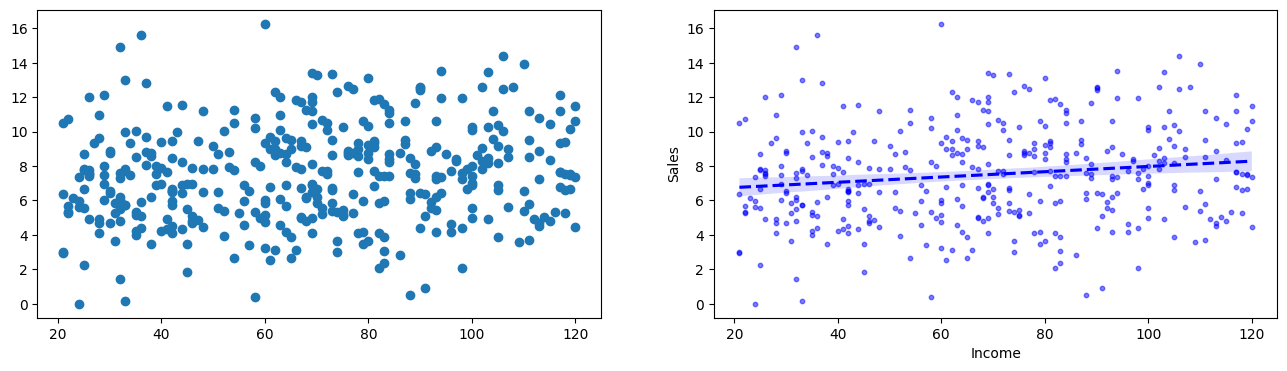

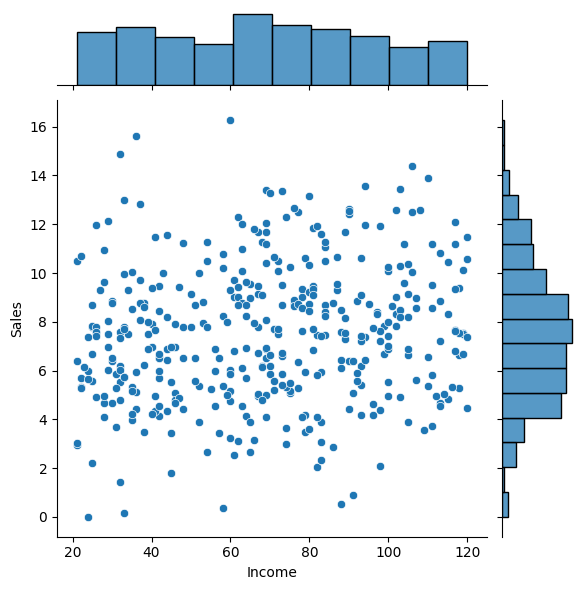

In [91]:

getGraph(df,'Income','Sales')

2) 수치화 : 상관분석

In [92]:
getStatics(df,'Income','Sales')

PearsonRResult(statistic=np.float64(0.15195097946754427), pvalue=np.float64(0.002309670453951773))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 상관관계 계수가 0.15로 상관관계는 미약하다.
- 하지만 pvalue는 0.02로 0.5보다 작으므로 통계적으로 유의미한 관계가있다.
- 소득이 높은 지역일수록 판매량이 약하게 증가하는 경향이있다.



---



# 3.범주형 X --> Y

* 모든 범자형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.

① 시각화 : 평균비교 barplot  
② 수치화 : t-test, anova

In [93]:
def getGraph2(df, x, y):
  sns.barplot(x=x, y=y, data=df)
  plt.grid()
  plt.show()

In [104]:
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US,df_comp
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes,18
1,11.22,111,48,16,260,83,Good,65,Yes,Yes,28
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes,33
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes,20
4,4.15,141,64,3,340,128,Bad,38,Yes,No,13


In [115]:
def getStatics2(df, x, y):
  temp = df[x].value_counts()
  list_m = []
  for i in temp.keys() :
      data = df.loc[df[x]== i, y]
      list_m.append(data)

  f_stat, p_value = spst.f_oneway(*list_m)
  print(f_stat, p_value)

### 3.1. ShelveLoc-> Sales

1) 시각화 : 평균비교 barplot

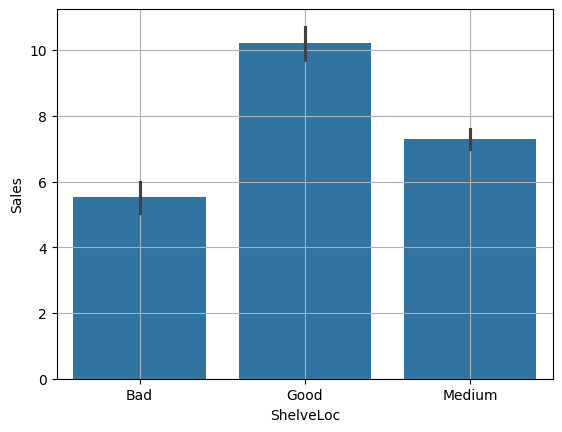

In [94]:
getGraph2(df, 'ShelveLoc', 'Sales')

2) 수치화 : t-test, anova

In [116]:
getStatics2(df, 'ShelveLoc', 'Sales')

92.22990509910348 1.2669360901591099e-33


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

ShelveLoc 상태에 따라 Bar차트 각 판매량의 평균수치 차이가 크고 f-통계랑 수치가 커 각 집단간의 판매량 차이가 명확하게 보일정도로 크다.
p_value도 0.05보다 작기 때문에 통계적으로 유의미한 정보로 생각된다

### 3.2. Urban -> Sales

1) 시각화 : 평균비교 barplot

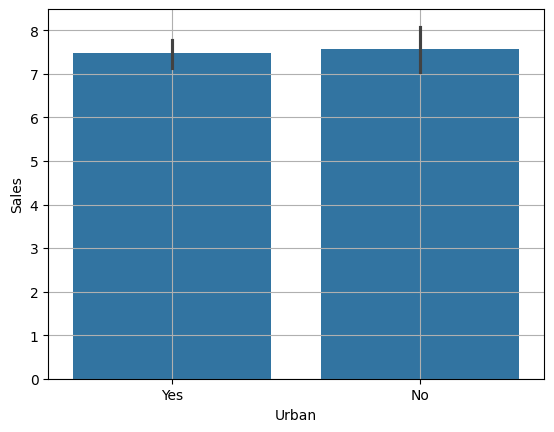

In [117]:
getGraph2(df, 'Urban', 'Sales')

2) 수치화 : t-test, anova

In [118]:
getStatics2(df, 'Urban', 'Sales')

0.09465065557659712 0.7585069603942758


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

Urban Y/N별 판매량을 Bar차트로 확인 시, 평균 수치의 차이가 미미하게 보이며, t-통계량 역시 -0.31로 2 미만으로 작은값이므로 상관 관계가 없다고 생각된다.
p_value는 0.75로 값은 0.05보다 크게 나왔다 (f-통계량 = 0.09)

### 3.3. US-> Sales

1) 시각화 : 평균비교 barplot

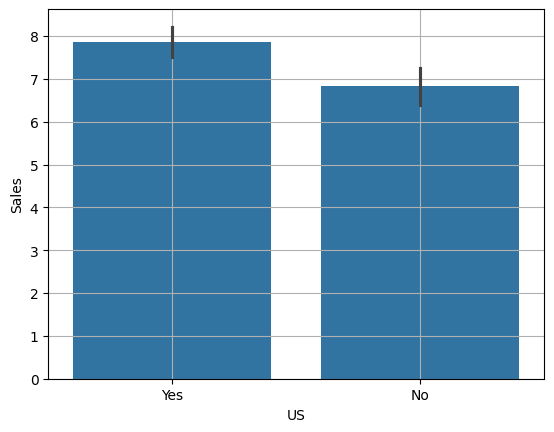

In [120]:
getGraph2(df, 'US', 'Sales')

2) 수치화 : t-test, anova

In [121]:
getStatics2(df, 'US', 'Sales')

12.88622427747462 0.0003723395870147218


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

bar차트 확인 시, 미국내 매장에서 판매량이 해외 판매량에 비해 수치가 높으며, t-통계량 수치도 3.5로 2를 넘겨 상관 관계가 있는 것으로 보인다.
(f-통계량 : 12.88) p_value로 0.05보다 작아 통계적으로 유의미하게 활용할 수 있다.

# 4.관계 정리하기

① 강한관계

In [ ]:

# - **ShelveLoc → Sales** : F=92, p≈0 (진열상태가 좋을수록 판매량 높음)
# - **PriceDiff → Sales** : r=0.59, p≈0 (가격 경쟁력이 높을수록 판매량 높음)

② 중간관계

In [ ]:

# - **Advertising → Sales** : r=0.27, p≈0 (광고비가 많을수록 판매량 높음)
# - **Age → Sales** : r=-0.23, p=0.000002 (연령이 낮을수록 판매량 높음)
# - **US → Sales** : t=3.58, p=0.0003 (미국 지역 매장이 판매량 높음)

③ 관계없음

In [ ]:

# - **Population → Sales** : r=0.04, p=0.5
# - **CompPrice → Sales** : r=0.06, p=0.2
# - **Income → Sales** : r=0.15, p=0.002 *(유의미하나 기준상 관계없음)*
# - **Urban → Sales** : t=-0.3, p=0.7

- 0.26의 상관관계를 보아 약한 양의 상관관계를 가지고있고
- p_value는 0.05보다 작으므로, 통계적으로 유의미한 관계를 가지고있다고 볼 수 있다.
============
- 기존의 0.26에서 0.25로 상관관계계수가 줄었지만 여전히 약한 양의 상관관계를 보이고있고.
- 기존의 0.00000004에서 0.00003으로 p_value가 늘어나긴했지만 여전히 통계적으로 유의미하다고 볼 수 있다.


- 0.05의 상관관계를 보아 거의 상관관계가 없다고 볼 수 있다.
- p_value는 0.3로 통계적 유의미한 관계가 없다. 해당변수는 Sales에 영향읆 미치지않는다.


- 상관관계 계수가 -0.44로 강한 음의 상관관계를 가지고있다.
- pvalue가 거의 0에 가까운 것으로 보아 Price와 Sales는 통계적으로 유의미한 관계가있다.
- 가격이 낮아질수록 판매량이 유의미하게 증가한다.


- 상관계수가 -0.23으로 중간정도의 음의 상관관계를 가진다.
- pvalue가 0.000002로 통계적으로 유의미한 관계가 있다.
- Age가 낮을수록 sale가 증가한다.


- 상관관계 계수가 0.06으로 선형성이 거의 없다.
- pvalue가 0.2로 통계적으로 유의미하지않다.
- 경쟁사의 가격은 우리의 판매량에 영향을 미치지 않는다.
============
- PriceDiff = CompPrice - Price
- 자사가격이 타사가격보다 낮을 경우 0.59의 강한 양의상관관계가 나타난다.
- p_vlaue또한 0에 수렴하는 값으로 통계적 유의미성이 상당히 크다.
- 단순 자사가격과 타사가격만 비교했을 때는 연관성이 없어보였지만, 가격경쟁력으로 비교를 하자 유의미한 차이를 볼 수 있다.
- 이는 단순히 가격이 싸고, 비싸고보다 경쟁사와의 가격차이가 판매량에 영향을 끼친다는 것을 보여준다




- 상관관계 계수가 0.15로 상관관계는 미약하다.
- 하지만 pvalue는 0.02로 0.5보다 작으므로 통계적으로 유의미한 관계가있다.
- 소득이 높은 지역일수록 판매량이 약하게 증가하는 경향이있다.

3.1
ShelveLoc 상태에 따라 Bar차트 각 판매량의 평균수치 차이가 크고 f-통계랑 수치가 커 각 집단간의 판매량 차이가 명확하게 보일정도로 크다.
p_value도 0.05보다 작기 때문에 통계적으로 유의미한 정보로 생각된다


Urban Y/N별 판매량을 Bar차트로 확인 시, 평균 수치의 차이가 미미하게 보이며, t-통계량 역시 -0.31로 2 미만으로 작은값이므로 상관 관계가 없다고 생각된다.
p_value는 0.75로 값은 0.05보다 크게 나왔다 (f-통계량 = 0.09)


bar차트 확인 시, 미국내 매장에서 판매량이 해외 판매량에 비해 수치가 높으며, t-통계량 수치도 3.5로 2를 넘겨 상관 관계가 있는 것으로 보인다.
(f-통계량 : 12.88) p_value로 0.05보다 작아 통계적으로 유의미하게 활용할 수 있다.




- **ShelveLoc → Sales** : F=92, p≈0 (진열상태가 좋을수록 판매량 높음)
- **PriceDiff → Sales** : r=0.59, p≈0 (가격 경쟁력이 높을수록 판매량 높음)
===========
- **Advertising → Sales** : r=0.27, p≈0 (광고비가 많을수록 판매량 높음)
- **Age → Sales** : r=-0.23, p=0.000002 (연령이 낮을수록 판매량 높음)
- **US → Sales** : t=3.58, p=0.0003 (미국 지역 매장이 판매량 높음)
===========
- **Population → Sales** : r=0.04, p=0.5
- **CompPrice → Sales** : r=0.06, p=0.2
- **Income → Sales** : r=0.15, p=0.002 *(유의미하나 기준상 관계없음)*
- **Urban → Sales** : t=-0.3, p=0.7


https://docs.google.com/spreadsheets/d/1pYU5V_izE_Ai3eJlFXjSR21FHfzhsZ4hvWOsOVV9Lvc/edit?gid=46390022#gid=46390022